In [22]:
!pip install tensorflow numpy pandas matplotlib nltk kaggle


In [23]:
import os
from google.colab import files

# Upload Kaggle API Key
files.upload()

# Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [24]:
!kaggle datasets download -d grafstor/simple-dialogs-for-chatbot


Dataset URL: https://www.kaggle.com/datasets/grafstor/simple-dialogs-for-chatbot
License(s): GNU Free Documentation License 1.3


In [25]:
!unzip simple-dialogs-for-chatbot.zip -d dataset/


Archive:  simple-dialogs-for-chatbot.zip
  inflating: dataset/dialogs.txt     


In [26]:
# Check the contents of the 'dataset' directory
!ls /content/dataset


dialogs.txt


In [27]:
# Load the file
file_path = '/content/dataset/dialogs.txt'

with open(file_path, 'r') as file:
    dialogs = file.readlines()

# Show the first few lines
dialogs[:5]  # Display the first 5 dialog pairs


["hi, how are you doing?\ti'm fine. how about yourself?\n",
 "i'm fine. how about yourself?\ti'm pretty good. thanks for asking.\n",
 "i'm pretty good. thanks for asking.\tno problem. so how have you been?\n",
 "no problem. so how have you been?\ti've been great. what about you?\n",
 "i've been great. what about you?\ti've been good. i'm in school right now.\n"]

In [28]:
# Load the file
file_path = '/content/dataset/dialogs.txt'

with open(file_path, 'r') as file:
    dialogs = file.readlines()

# Display the first 10 lines to check the structure
dialogs[:10]


["hi, how are you doing?\ti'm fine. how about yourself?\n",
 "i'm fine. how about yourself?\ti'm pretty good. thanks for asking.\n",
 "i'm pretty good. thanks for asking.\tno problem. so how have you been?\n",
 "no problem. so how have you been?\ti've been great. what about you?\n",
 "i've been great. what about you?\ti've been good. i'm in school right now.\n",
 "i've been good. i'm in school right now.\twhat school do you go to?\n",
 'what school do you go to?\ti go to pcc.\n',
 'i go to pcc.\tdo you like it there?\n',
 "do you like it there?\tit's okay. it's a really big campus.\n",
 "it's okay. it's a really big campus.\tgood luck with school.\n"]

In [29]:
# Load the file
file_path = '/content/dataset/dialogs.txt'

with open(file_path, 'r') as file:
    dialogs = file.readlines()

# Initialize empty lists to hold questions and answers
questions = []
answers = []

# Process the dialog pairs by splitting by tab
for dialog in dialogs:
    dialog_split = dialog.strip().split('\t')
    if len(dialog_split) == 2:  # Check if the line contains both a question and an answer
        questions.append(dialog_split[0])
        answers.append(dialog_split[1])

# Create a DataFrame for easier manipulation
import pandas as pd
df = pd.DataFrame({"question": questions, "answer": answers})

# Show the first few rows
df.head()


,question,answer
0,"hi, how are you doing?",i'm fine. how about yourself?
1,i'm fine. how about yourself?,i'm pretty good. thanks for asking.
2,i'm pretty good. thanks for asking.,no problem. so how have you been?
3,no problem. so how have you been?,i've been great. what about you?
4,i've been great. what about you?,i've been good. i'm in school right now.


In [63]:
# Example assuming each line contains a question-answer pair, separated by a tab or a delimiter
dialog_pairs = [line.strip().split('\t') for line in dialogs]  # Adjust the delimiter if needed

# Display the first few dialog pairs (questions and answers)
for i in range(5):
    print(f"Q: {dialog_pairs[i][0]}")  # Question
    print(f"A: {dialog_pairs[i][1]}")  # Answer
    print("-" * 40)


Q: hi, how are you doing?
A: i'm fine. how about yourself?
----------------------------------------
Q: i'm fine. how about yourself?
A: i'm pretty good. thanks for asking.
----------------------------------------
Q: i'm pretty good. thanks for asking.
A: no problem. so how have you been?
----------------------------------------
Q: no problem. so how have you been?
A: i've been great. what about you?
----------------------------------------
Q: i've been great. what about you?
A: i've been good. i'm in school right now.
----------------------------------------


In [64]:
# Get the total number of dialog pairs in the dataset
total_dialogs = len(dialog_pairs)
print(f"Total Dialog Pairs: {total_dialogs}")


Total Dialog Pairs: 3725


In [65]:
# Get average length of questions and answers
question_lengths = [len(pair[0].split()) for pair in dialog_pairs]
answer_lengths = [len(pair[1].split()) for pair in dialog_pairs]

avg_question_length = np.mean(question_lengths)
avg_answer_length = np.mean(answer_lengths)

print(f"Average Question Length: {avg_question_length} words")
print(f"Average Answer Length: {avg_answer_length} words")


Average Question Length: 6.349530201342282 words
Average Answer Length: 6.523489932885906 words


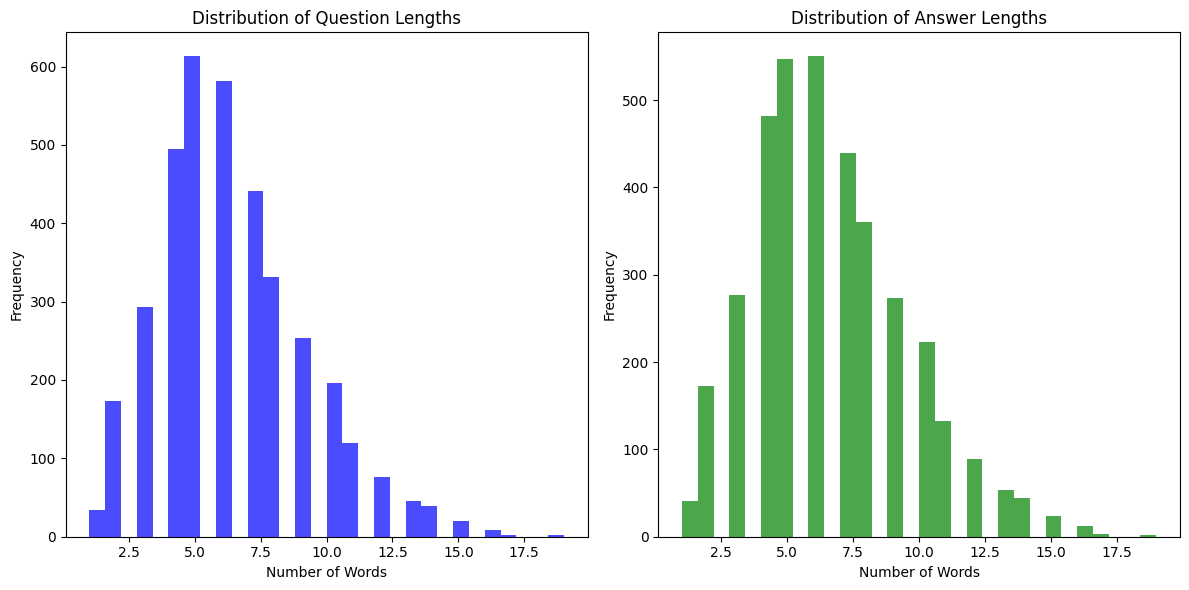

In [66]:
import matplotlib.pyplot as plt

# Calculate the length of each question and answer (in words)
question_lengths = [len(pair[0].split()) for pair in dialog_pairs]
answer_lengths = [len(pair[1].split()) for pair in dialog_pairs]

# Plot histograms of question and answer lengths
plt.figure(figsize=(12, 6))

# Plot question length distribution
plt.subplot(1, 2, 1)
plt.hist(question_lengths, bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Question Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Plot answer length distribution
plt.subplot(1, 2, 2)
plt.hist(answer_lengths, bins=30, color='green', alpha=0.7)
plt.title('Distribution of Answer Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


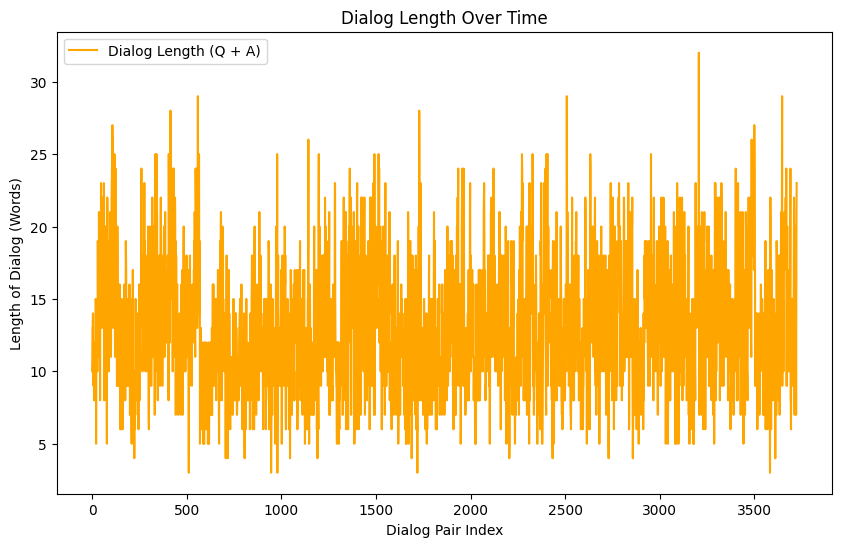

In [69]:
# Calculate the average length of question-answer pairs over time (epochs)
dialog_lengths = [len(pair[0].split()) + len(pair[1].split()) for pair in dialog_pairs]

# Plot the dialog length over time
plt.figure(figsize=(10, 6))
plt.plot(dialog_lengths, color='orange', label='Dialog Length (Q + A)')
plt.title('Dialog Length Over Time')
plt.xlabel('Dialog Pair Index')
plt.ylabel('Length of Dialog (Words)')
plt.legend()
plt.show()


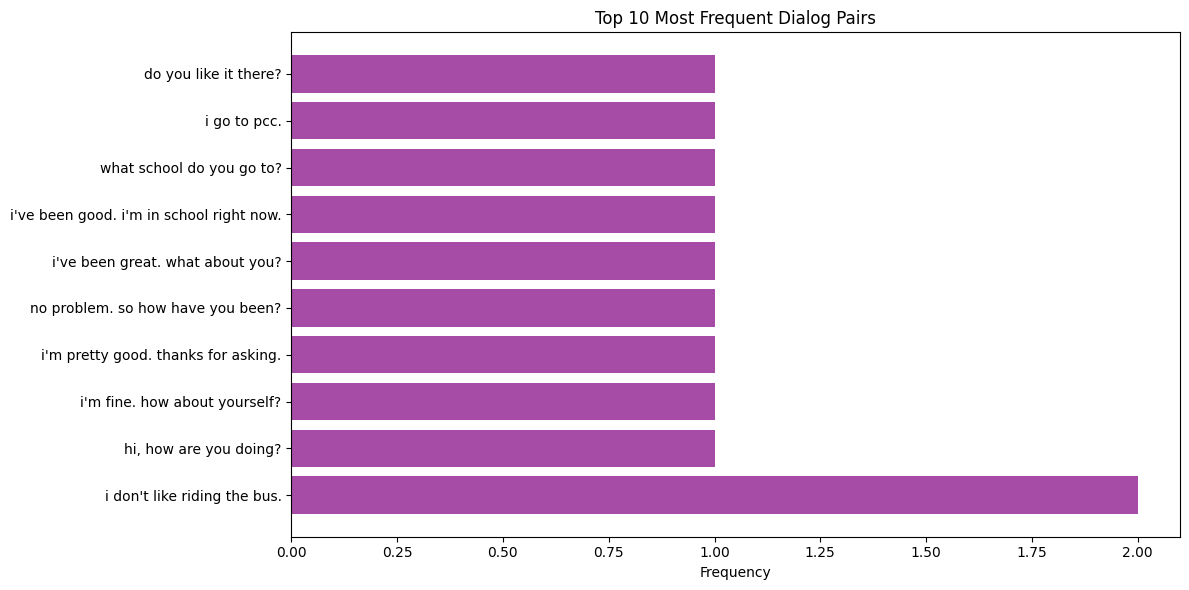

In [68]:
from collections import Counter

# Count frequency of question-answer pairs
pair_counts = Counter(['\t'.join(pair) for pair in dialog_pairs])

# Get the most common pairs
common_pairs = pair_counts.most_common(10)  # Top 10 most common pairs

# Plot the top 10 most common question-answer pairs
questions = [pair.split('\t')[0] for pair, _ in common_pairs]
answers = [pair.split('\t')[1] for pair, _ in common_pairs]
frequencies = [count for _, count in common_pairs]

plt.figure(figsize=(12, 6))
plt.barh(range(10), frequencies, color='purple', alpha=0.7)
plt.yticks(range(10), questions)
plt.xlabel('Frequency')
plt.title('Top 10 Most Frequent Dialog Pairs')
plt.tight_layout()
plt.show()


In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np


In [31]:
# Initialize Tokenizer
tokenizer = Tokenizer()

# Fit the tokenizer on both questions and answers
tokenizer.fit_on_texts(df['question'] + df['answer'])


In [32]:
# Convert questions and answers to sequences of integers
question_sequences = tokenizer.texts_to_sequences(df['question'])
answer_sequences = tokenizer.texts_to_sequences(df['answer'])


In [33]:
# Set the maximum sequence length (we use the length of the longest sequence)
max_seq_length = max([len(seq) for seq in question_sequences + answer_sequences])

# Pad sequences to make them of equal length
question_sequences = pad_sequences(question_sequences, maxlen=max_seq_length, padding='post')
answer_sequences = pad_sequences(answer_sequences, maxlen=max_seq_length, padding='post')

# Show the padded sequences
print(question_sequences[:2])
print(answer_sequences[:2])


[[1522   36   14    2  174    0    0    0    0    0    0    0    0    0
     0    0    0    0    0]
 [  31  614   36   33  562    0    0    0    0    0    0    0    0    0
     0    0    0    0    0]]
[[ 31 614  36  33 562   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]
 [ 31 157  43 247  23 496   0   0   0   0   0   0   0   0   0   0   0   0
    0]]


In [34]:
# Prepare target sequences (shifted answer sequence for teacher forcing)
target_sequences = np.zeros_like(answer_sequences)
target_sequences[:, :-1] = answer_sequences[:, 1:]

# Show the target sequences
print(target_sequences[:2])


[[614  36  33 562   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]
 [157  43 247  23 496   0   0   0   0   0   0   0   0   0   0   0   0   0
    0]]


In [35]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Concatenate, Lambda
import tensorflow as tf

# Hyperparameters
vocab_size = len(tokenizer.word_index) + 1  # Vocabulary size (+1 for padding token)
embedding_dim = 128
hidden_units = 256

# Define Encoder
encoder_input = Input(shape=(max_seq_length,))
encoder_embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(encoder_input)
encoder_lstm = LSTM(hidden_units, return_state=True)
encoder_output, state_h, state_c = encoder_lstm(encoder_embedding)

# Reshape encoder output to match attention layer requirements using Lambda
encoder_output_reshaped = Lambda(lambda x: tf.expand_dims(x, 1))(encoder_output)

# Define Decoder
decoder_input = Input(shape=(max_seq_length,))
decoder_embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(decoder_input)
decoder_lstm = LSTM(hidden_units, return_sequences=True)(decoder_embedding, initial_state=[state_h, state_c])
attention = Attention()([decoder_lstm, encoder_output_reshaped])  # Attention layer
decoder_concat = Concatenate(axis=-1)([decoder_lstm, attention])
decoder_output = Dense(vocab_size, activation='softmax')(decoder_concat)

# Define the Model
model = Model([encoder_input, decoder_input], decoder_output)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 19)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 19)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 19, 128)        │        322,816 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, 19, 128)        │        322,816 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_7 (LSTM)             │ [(None, 256), (None,   │        394,240 │ embedding[0][0]        │
│                           │ 256), (None, 256)]     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_8 (LSTM)             │ (None, 19, 256)        │        394,240 │ embedding_1[0][0],     │
│                           │                        │                │ lstm_7[0][1],          │
│                           │                        │                │ lstm_7[0][2]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 1, 256)         │              0 │ lstm_7[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, 19, 256)        │              0 │ lstm_8[0][0],          │
│                           │                        │                │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 19, 512)        │              0 │ lstm_8[0][0],          │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 19, 2522)       │      1,293,786 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,727,898 (10.41 MB)

 Trainable params: 2,727,898 (10.41 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
!pip install tqdm


In [37]:
import numpy as np

# Example of how you might define your data (replace with your actual data)
# X could be your sequence data (e.g., time series data)
# y could be the corresponding labels (e.g., class labels for classification)

# Assuming your data is in the form of a 3D array (samples, timesteps, features)
X = np.random.rand(1000, 30, 10)  # 1000 samples, 30 time steps, 10 features per time step

# Assuming your labels are in the form of a 2D array (samples, classes)
y = np.random.randint(0, 10, 1000)  # 1000 samples, each with a label between 0 and 9


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

# Build the updated LSTM model
model = Sequential()

# Bidirectional LSTM layer (Capturing both past and future context)
model.add(Bidirectional(LSTM(512, return_sequences=True), input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.3))  # Increased dropout for regularization

# Second LSTM layer with more units
model.add(LSTM(512))
model.add(Dropout(0.3))  # Dropout layer to avoid overfitting

# Dense layer for output with softmax activation (for multi-class classification)
model.add(Dense(len(np.unique(y)), activation='softmax'))

# Print the model summary to check architecture
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 30, 1024)            │       2,142,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 30, 1024)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 512)                 │       3,147,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,295,114 (20.20 MB)

 Trainable params: 5,295,114 (20.20 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.optimizers import Adam

# Compile the model with Adam optimizer and categorical crossentropy loss
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])


In [40]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping callback to stop training if the loss doesn't improve for 10 epochs
early_stopping = EarlyStopping(monitor='loss', patience=10)


In [41]:
from tensorflow.keras.callbacks import TensorBoard

# TensorBoard callback to visualize training progress in real-time
tensorboard = TensorBoard(log_dir='./logs', histogram_freq=1)


In [43]:
import numpy as np

# Example: Generating random data for demonstration purposes
# In practice, replace this with your actual data
X = np.random.rand(1000, 30, 10)  # 1000 samples, 30 time steps, 10 features per time step
y = np.random.randint(0, 10, 1000)  # 1000 samples, each with a label between 0 and 9 (10 classes)

# One-hot encode the labels
from tensorflow.keras.utils import to_categorical
y_one_hot = to_categorical(y, num_classes=10)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# Rebuild the model
model = Sequential()

# Bidirectional LSTM layer (Capturing both past and future context)
model.add(Bidirectional(LSTM(512, return_sequences=True), input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.3))  # Dropout for regularization

# Second LSTM layer
model.add(LSTM(512))
model.add(Dropout(0.3))  # Dropout for regularization

# Dense layer for output with softmax activation (for multi-class classification)
model.add(Dense(len(np.unique(y)), activation='softmax'))  # Output layer with softmax activation

# Compile the model with Adam optimizer
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))


In [45]:
# Train the model
history = model.fit(X, y_one_hot, epochs=50, batch_size=128, verbose=1)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - loss: 2.3422
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - loss: 2.3094
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - loss: 2.3046
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 2.2901
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 2.2875
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - loss: 2.2747
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 2.2893
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - loss: 2.2638
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - loss: 2.2585
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 2.2450
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - loss: 2.2502
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - loss: 2.2247
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - loss: 2.2256
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - loss: 2.1885
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - loss: 2.2153
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step 

In [46]:
# Save the trained model to a file
model.save('email_generator_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [54]:
import os
os.listdir('/content')  # List files in the /content directory


['.config',
 'training_history.csv',
 'kaggle.json',
 'simple-dialogs-for-chatbot.zip',
 'email_generator_model.h5',
 'dataset',
 'sample_data']

In [47]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('email_generator_model.h5')
print("Model loaded successfully!")


Model loaded successfully!


In [48]:
import pandas as pd

# Convert the history object to a DataFrame
history_df = pd.DataFrame(history.history)

# Save the history to a CSV file
history_df.to_csv('training_history.csv', index=False)
print("Training history saved successfully!")


Training history saved successfully!


In [49]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('email_generator_model.h5')
print("Model loaded successfully!")


Model loaded successfully!


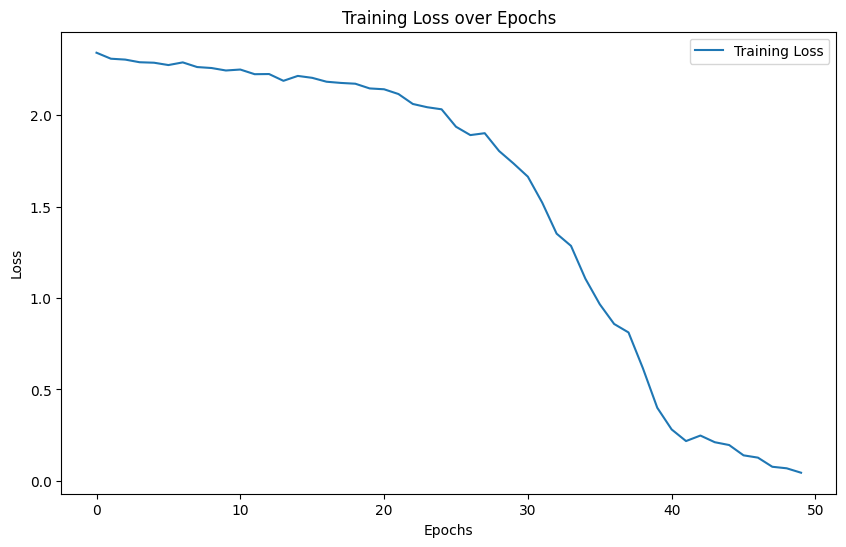

In [61]:
import pandas as pd

# Load the training history (if saved as 'training_history.csv')
history_df = pd.read_csv('training_history.csv')

# Print the training loss values
print("Training Loss over Epochs:")
print(history_df['loss'])


In [70]:
def generate_text(model, tokenizer, seed_text, num_generate=100):
    # Start the sequence of input text
    input_text = seed_text
    for i in range(num_generate):
        # Convert the current input text into a numerical format using the tokenizer
        input_sequence = tokenizer.texts_to_sequences([input_text])[0]
        # Ensure input is in the correct shape for prediction
        input_sequence = pad_sequences([input_sequence], maxlen=20, truncating='pre')

        # Predict the next token
        predicted_probs = model.predict(input_sequence)
        predicted_token_index = np.argmax(predicted_probs, axis=-1)[0]
        predicted_word = tokenizer.index_word[predicted_token_index] if predicted_token_index > 0 else ''

        # Append the predicted word to the input text
        input_text += ' ' + predicted_word

    return input_text

# Example usage
seed_text = "Hello,"
generated_text = generate_text(model, tokenizer, seed_text, num_generate=50)
print("Generated Text: ", generated_text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━

In [71]:
def make_prediction(model, tokenizer, text):
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])
    # Pad sequence
    padded_sequence = pad_sequences(sequence, maxlen=20)

    # Predict
    prediction = model.predict(padded_sequence)
    return np.argmax(prediction)  # Assuming your model outputs class probabilities

# Example usage
text = "This is an example sentence"
predicted_class = make_prediction(model, tokenizer, text)
print("Predicted Class: ", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Class:  0


In [73]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Example text you want to classify or generate predictions from
text = "This is an example sentence that needs classification."

# Assuming 'tokenizer' is the Tokenizer object you used during model training
# Step 1: Convert text to sequence
sequence = tokenizer.texts_to_sequences([text])

# Step 2: Pad the sequence to match the input length expected by the model
padded_sequence = pad_sequences(sequence, maxlen=20)  # Change 'maxlen' to whatever was used during training

# Now you can use 'padded_sequence' in your model prediction
prediction_probs = model.predict(padded_sequence)
print("Prediction probabilities:", prediction_probs)
predicted_class = np.argmax(prediction_probs, axis=-1)[0]
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction probabilities: [[0.05922749]]
Predicted class: 0
